Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries installed
✅ Libraries loaded
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB
✅ Features dir : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features
✅ Figures dir  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
✅ Model        : esm2_t33_650M_UR50D
✅ Batch size   : 16
✅ Pooling      : mean
✅ Parsed 2435 sequences
   Positive (AIP)    : 974
   Negative (non-AIP): 1461
   Length range      : 11 – 46 aa
Loading ESM-2 model: esm2_t33_650M_UR50D
(First run downloads model weights — cached afterwards)

✅ ESM-2 model loaded
   Parameters    : 651M
   Layers        : 33
   Embedding dim : 1280
   Repr layer    : 33 (last layer)
Original  : PRIVLDVASSVF
Processed : PRIVLDVASSVF

✅ No space formatting needed (unlike ProtBERT/ProtT5)
Extracting ESM-2 embeddings...
  Sequences     : 2435
  Batch size    : 16
  Repr layer    : 33/33
  Pooling

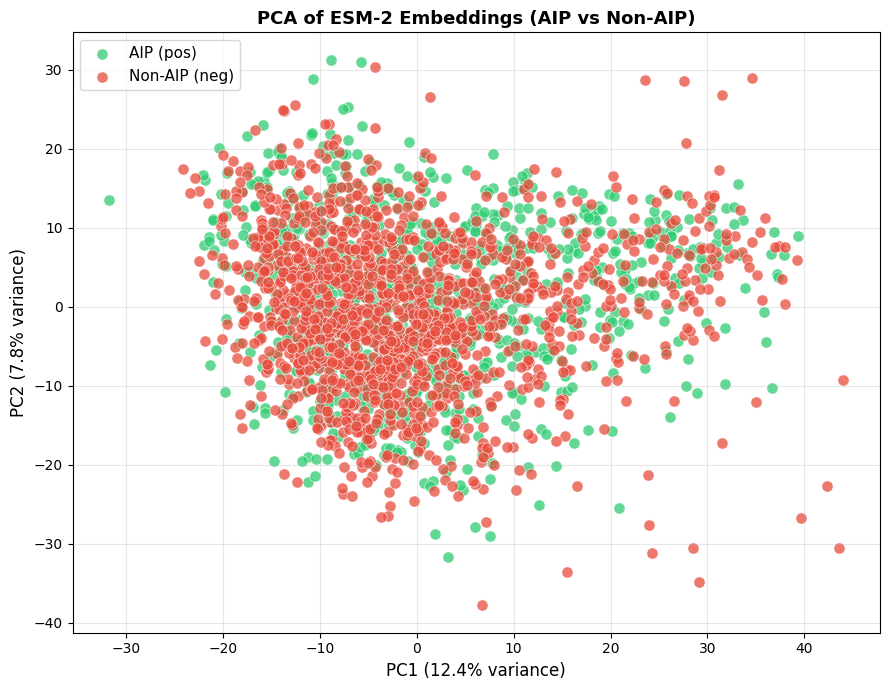

✅ PCA plot saved
Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


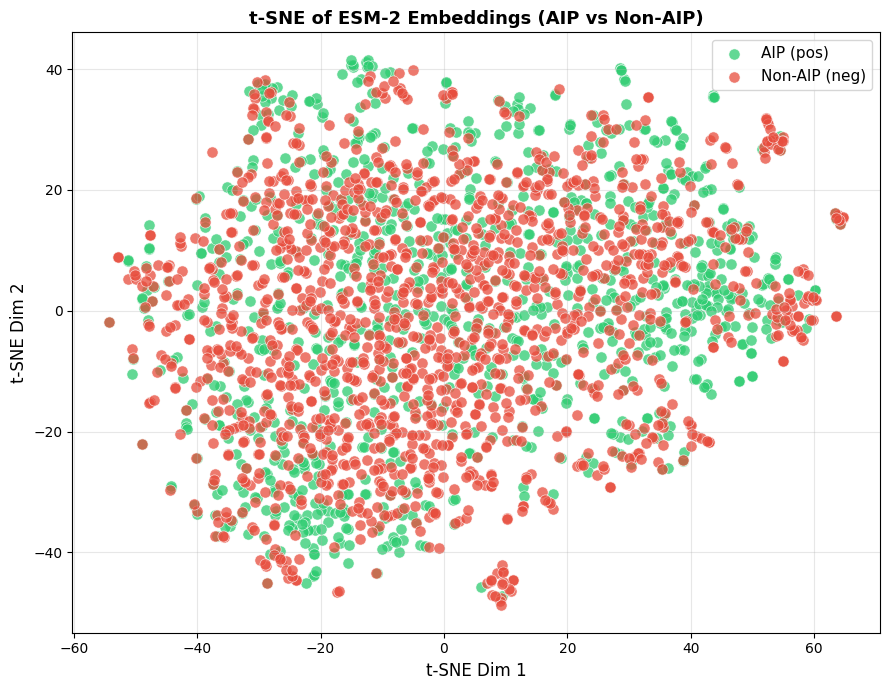

✅ t-SNE plot saved
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


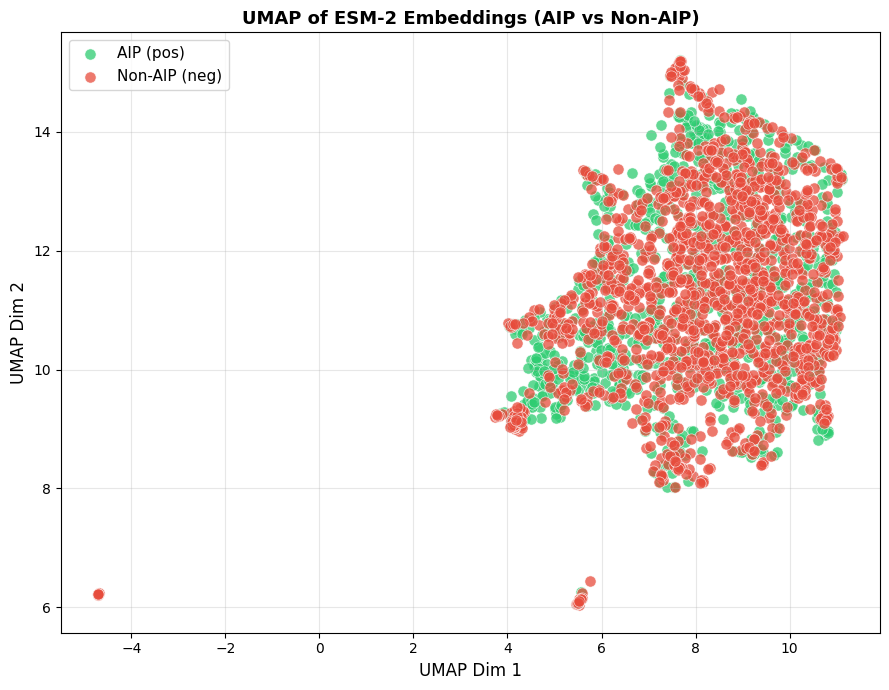

✅ UMAP plot saved


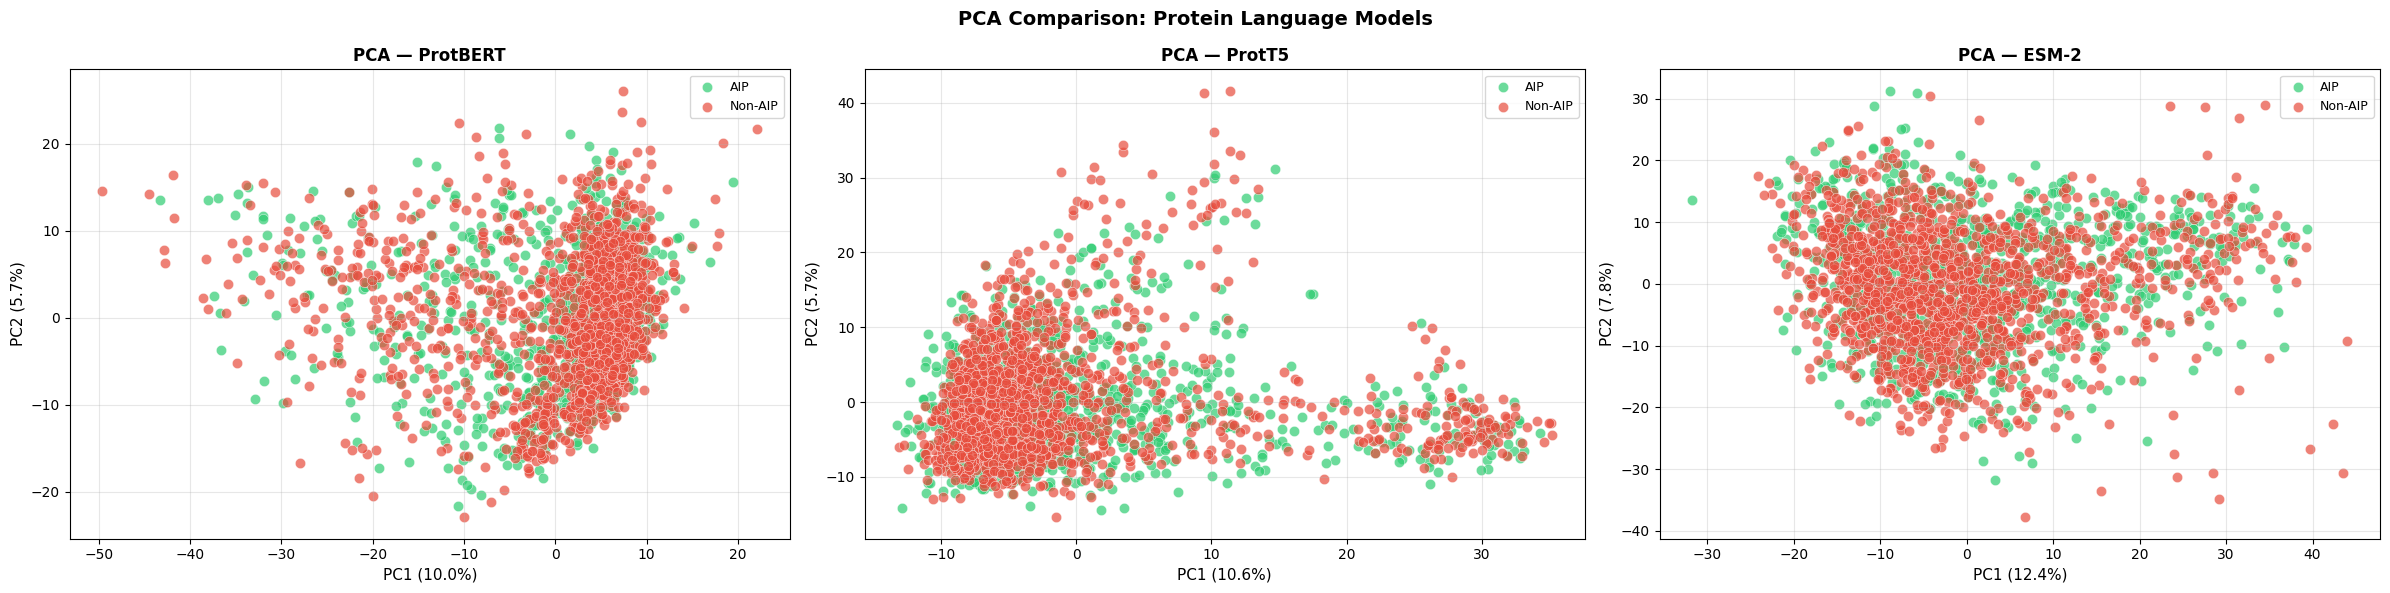

✅ PLM comparison plot saved


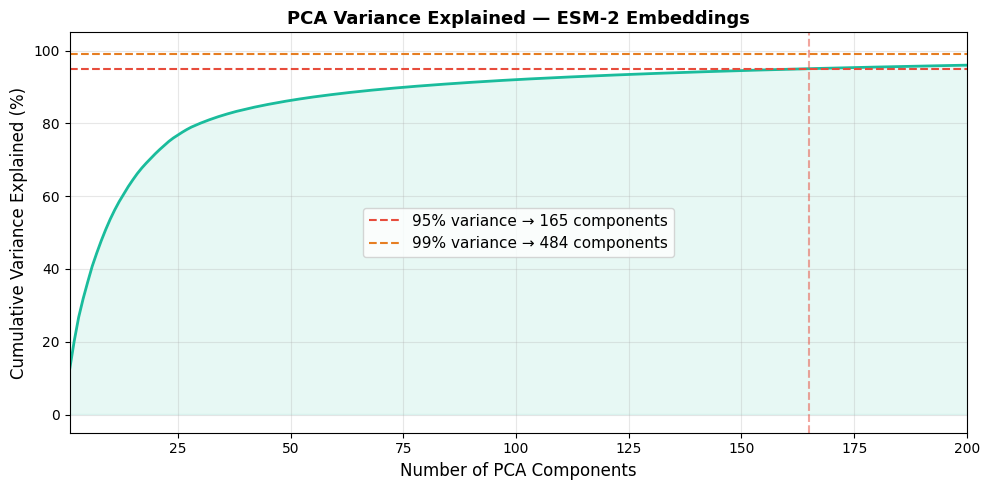

✅ Variance plot saved
   165 components → 95% variance  (vs full 1280 dims)
   484 components → 99% variance
✅ PCA-reduced features saved
   File  : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ESM2_PCA_features.csv
   Shape : (2435, 168)  (165 dims vs original 1280)
✅ ESM-2 Feature Extraction COMPLETE
   Full CSV   : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ESM2_features.csv
   Shape      : (2435, 1282)
   Raw .npy   : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ESM2_embeddings.npy
   PCA CSV    : /content/drive/MyDrive/Colab Notebooks/AIP_V2/features/ESM2_PCA_features.csv
   PCA Shape  : (2435, 168)
   Figures    : /content/drive/MyDrive/Colab Notebooks/AIP_V2/figures
   Model      : esm2_t33_650M_UR50D
   Layer      : 33/33
   Pooling    : mean


In [ ]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install Required Libraries
# ============================================================
!pip install fair-esm torch umap-learn -q

print("✅ Libraries installed")


# ============================================================
#   CELL 3 — Import Libraries
# ============================================================
import os
import gc
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import esm
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Check GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Libraries loaded")
print(f"   Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU — running on CPU (slower)")


# ============================================================
#   CELL 4 — Configuration (Edit paths here)
# ============================================================

# FOR DRIVE FILE LOCATION
FASTA_PATH  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/data/AIP.fasta"
OUTPUT_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/features"
FIGURES_DIR = "/content/drive/MyDrive/Colab Notebooks/AIP_V2/figures"

# FOR LOCAL
# FASTA_PATH  = "../../data/raw/AIP_ind.fasta"
# OUTPUT_DIR  = "../../data/features"
# OUTPUT_DIR  = "../../results/figures"

OUTPUT_CSV  = os.path.join(OUTPUT_DIR, "ESM2_features.csv")
OUTPUT_NPY  = os.path.join(OUTPUT_DIR, "ESM2_embeddings.npy")

# ── ESM-2 Model Variants ────────────────────────────────────
#  Model                       Params  Embed-dim  VRAM
#  esm2_t6_8M_UR50D             8M      320        <1 GB  (fast/CPU)
#  esm2_t12_35M_UR50D           35M     480        ~1 GB
#  esm2_t30_150M_UR50D          150M    640        ~2 GB
#  esm2_t33_650M_UR50D          650M    1280       ~4 GB  ✅ recommended
#  esm2_t36_3B_UR50D            3B      2560       ~12 GB
#
#  ✅ Recommended for Colab T4 (16 GB): esm2_t33_650M_UR50D
#  🔁 If OOM error: switch to esm2_t30_150M_UR50D
# ────────────────────────────────────────────────────────────
MODEL_NAME  = "esm2_t33_650M_UR50D"

# Reduce if you get OOM error
BATCH_SIZE  = 16

# Pooling: "mean" (recommended), "cls", or "max"
POOLING     = "mean"

# -1 = use last layer (best for classification tasks)
REPR_LAYER  = -1

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"✅ Features dir : {OUTPUT_DIR}")
print(f"✅ Figures dir  : {FIGURES_DIR}")
print(f"✅ Model        : {MODEL_NAME}")
print(f"✅ Batch size   : {BATCH_SIZE}")
print(f"✅ Pooling      : {POOLING}")


# ============================================================
#   CELL 5 — FASTA Parser
# ============================================================

def parse_fasta(filepath):
    """Parse FASTA file → DataFrame with seq_id, sequence, label"""
    entries    = []
    current_id = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
            elif line and current_id:
                label = 1 if current_id.startswith("pos") else 0
                entries.append({
                    "seq_id"  : current_id,
                    "sequence": line.upper(),
                    "label"   : label
                })

    df = pd.DataFrame(entries)
    print(f"✅ Parsed {len(df)} sequences")
    print(f"   Positive (AIP)    : {df['label'].sum()}")
    print(f"   Negative (non-AIP): {(df['label']==0).sum()}")
    print(f"   Length range      : {df['sequence'].apply(len).min()} – "
          f"{df['sequence'].apply(len).max()} aa")
    return df

df_seq = parse_fasta(FASTA_PATH)
df_seq.head(3)


# ============================================================
#   CELL 6 — Load ESM-2 Model & Alphabet
# ============================================================
#
#  ESM-2 key advantages over ProtBERT / ProtT5:
#  ✅ No space formatting — takes raw sequences directly
#  ✅ Built-in batch converter handles padding automatically
#  ✅ Multiple model sizes for different compute budgets
#  ✅ Uses its own alphabet — no HuggingFace tokenizer needed
#
# ============================================================

print(f"Loading ESM-2 model: {MODEL_NAME}")
print("(First run downloads model weights — cached afterwards)\n")

esm_model, alphabet = esm.pretrained.load_model_and_alphabet(MODEL_NAME)

# Resolve last layer number
NUM_LAYERS = esm_model.num_layers
REPR_LAYER = NUM_LAYERS if REPR_LAYER == -1 else REPR_LAYER

esm_model = esm_model.to(DEVICE)
esm_model.eval()

# Built-in batch converter — handles tokenisation + padding
batch_converter = alphabet.get_batch_converter()

print(f"✅ ESM-2 model loaded")
print(f"   Parameters    : {sum(p.numel() for p in esm_model.parameters())/1e6:.0f}M")
print(f"   Layers        : {NUM_LAYERS}")
print(f"   Embedding dim : {esm_model.embed_dim}")
print(f"   Repr layer    : {REPR_LAYER} (last layer)")


# ============================================================
#   CELL 7 — Sequence Preprocessing
# ============================================================
#
#  ✅ ESM-2 takes RAW sequences — NO space formatting needed
#     (unlike ProtBERT and ProtT5 which require "A C D E")
#
#  Replace non-standard amino acids:
#     U → C  (Selenocysteine)
#     B, Z, O → X  (ambiguous)
#
# ============================================================

def preprocess_sequence(sequence):
    """
    Minimal preprocessing for ESM-2:
    1. Uppercase
    2. Replace non-standard AAs
    No space-separation needed.
    """
    sequence = sequence.upper()
    sequence = re.sub(r"[UZOB]", "X", sequence)
    return sequence


sample    = df_seq["sequence"].iloc[0]
processed = preprocess_sequence(sample)
print(f"Original  : {sample}")
print(f"Processed : {processed}")
print(f"\n✅ No space formatting needed (unlike ProtBERT/ProtT5)")


# ============================================================
#   CELL 8 — ESM-2 Embedding Extraction  (FIXED)
# ============================================================

def pool_embeddings_esm(token_representations, lengths, strategy="mean"):
    """
    Pool per-residue embeddings → one fixed-size vector per sequence.

    ESM-2 token layout:
      position 0      = <cls> token
      position 1..L   = amino acid tokens  (L = sequence length)
      position L+1    = <eos> token

    We use only positions 1..L for pooling (residue tokens only).
    """
    batch_size = token_representations.shape[0]
    embed_dim  = token_representations.shape[2]
    pooled     = torch.zeros(batch_size, embed_dim)

    for i, length in enumerate(lengths):
        # Slice residue tokens only — skip <cls> at position 0
        residue_tokens = token_representations[i, 1: length + 1]

        if strategy == "mean":
            pooled[i] = residue_tokens.mean(dim=0)
        elif strategy == "cls":
            # Use <cls> token at position 0
            pooled[i] = token_representations[i, 0]
        elif strategy == "max":
            pooled[i] = residue_tokens.max(dim=0).values
        else:
            raise ValueError(f"Unknown pooling strategy: '{strategy}'. "
                             f"Choose 'mean', 'cls', or 'max'.")
    return pooled


def extract_esm2_embeddings(df, esm_model, batch_converter,
                             device, batch_size=BATCH_SIZE,
                             repr_layer=REPR_LAYER,
                             pooling=POOLING):
    """
    Extract ESM-2 embeddings for all sequences in batches.

    ✅ FIX: ESM-2 forward() only accepts:
            esm_model(tokens, repr_layers=[N], return_contacts=False)
            The argument 'return_representation' does NOT exist —
            representations are returned automatically when
            repr_layers is specified.

    Returns:
        embeddings : np.ndarray shape (N, embed_dim)
    """
    sequences      = df["sequence"].tolist()
    seq_ids        = df["seq_id"].tolist()
    n_sequences    = len(sequences)
    all_embeddings = []

    print(f"Extracting ESM-2 embeddings...")
    print(f"  Sequences     : {n_sequences}")
    print(f"  Batch size    : {batch_size}")
    print(f"  Repr layer    : {repr_layer}/{NUM_LAYERS}")
    print(f"  Pooling       : {pooling}")
    print(f"  Device        : {device}\n")

    with torch.no_grad():
        for start in range(0, n_sequences, batch_size):
            end           = min(start + batch_size, n_sequences)
            batch_seqs    = sequences[start:end]
            batch_ids     = seq_ids[start:end]
            batch_lengths = [len(s) for s in batch_seqs]

            # Preprocess
            batch_seqs_clean = [preprocess_sequence(s) for s in batch_seqs]

            # ESM-2 expects list of (label, sequence) tuples
            batch_input = list(zip(batch_ids, batch_seqs_clean))

            # Tokenise + pad + convert to tensor
            _, _, batch_tokens = batch_converter(batch_input)
            batch_tokens = batch_tokens.to(device)

            # ✅ FIXED: only repr_layers and return_contacts are valid args
            #           'return_representation' does NOT exist in ESM-2
            results = esm_model(
                batch_tokens,
                repr_layers     = [repr_layer],
                return_contacts = False
            )

            # Representations are under results["representations"][layer]
            token_repr = results["representations"][repr_layer]

            # Pool → (batch, embed_dim)
            pooled = pool_embeddings_esm(
                token_repr.cpu(), batch_lengths, strategy=pooling
            )

            all_embeddings.append(pooled.numpy())

            print(f"  [{end:>4}/{n_sequences}] done")

            # Free GPU cache periodically
            if device.type == "cuda":
                torch.cuda.empty_cache()
                gc.collect()

    embeddings = np.vstack(all_embeddings)
    print(f"\n✅ Extraction complete — shape: {embeddings.shape}")
    return embeddings


embeddings = extract_esm2_embeddings(
    df_seq, esm_model, batch_converter, DEVICE
)


# ============================================================
#   CELL 9 — Build Feature DataFrame
# ============================================================

embedding_dim = embeddings.shape[1]
col_names     = [f"ESM2_{i}" for i in range(embedding_dim)]

df_emb  = pd.DataFrame(embeddings, columns=col_names)
df_esm2 = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_emb
], axis=1)
# ── REMOVED ──────────────────────────────────────────────
# df_esm2.insert(2, "length", df_esm2["sequence"].apply(len))
# ─────────────────────────────────────────────────────────────────

# ── CHANGED (Block): drop sequence & length, move label to end ──
df_esm2 = df_esm2.drop(columns=["sequence"])                        # ← remove sequence column
cols   = [c for c in df_esm2.columns if c != "label"] + ["label"] # ← move label to end
df_esm2 = df_esm2[cols]                                             # ← reorder columns
# ────────────────────────────────────────────────────────────────

emb_cols = [c for c in df_esm2.columns if c.startswith("ESM2_")]

print(f"✅ Feature DataFrame built")
print(f"   Shape   : {df_esm2.shape}")
print(f"      Columns : seq_id, ESM2_0...ESM2_N (embedding features), label")  # ← CHANGED: updated column description
df_esm2.iloc[:3, :8]


# ============================================================
#   CELL 10 — Validate Output
# ============================================================

print("── Validation ──────────────────────────────────────")
print(f"Embedding dimension  : {len(emb_cols)}")
print(f"Missing values       : {df_esm2[emb_cols].isnull().sum().sum()}")
print(f"Value range          : {df_esm2[emb_cols].values.min():.4f} – "
      f"{df_esm2[emb_cols].values.max():.4f}")
print(f"Mean (pos class)     : "
      f"{df_esm2[df_esm2['label']==1][emb_cols].values.mean():.6f}")
print(f"Mean (neg class)     : "
      f"{df_esm2[df_esm2['label']==0][emb_cols].values.mean():.6f}")
print(f"Std  (pos class)     : "
      f"{df_esm2[df_esm2['label']==1][emb_cols].values.std():.6f}")
print(f"Std  (neg class)     : "
      f"{df_esm2[df_esm2['label']==0][emb_cols].values.std():.6f}")
print("✅ Validation complete")


# ============================================================
#   CELL 11 — Scale Embeddings for Visualization
# ============================================================

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_esm2[emb_cols].values)
print(f"✅ Scaled — shape: {X_scaled.shape}  mean≈0  std≈1")


# ============================================================
#   CELL 12 — Visualization 1: PCA 2D Plot
# ============================================================

pca_2d  = PCA(n_components=2, random_state=42)
X_pca   = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_esm2["label"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("PCA of ESM-2 Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ESM2_PCA.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ PCA plot saved")


# ============================================================
#   CELL 13 — Visualization 2: t-SNE 2D Plot
# ============================================================

print("Running t-SNE...")
tsne   = TSNE(n_components=2, random_state=42,
              perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_esm2["label"] == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel("t-SNE Dim 1", fontsize=12)
ax.set_ylabel("t-SNE Dim 2", fontsize=12)
ax.set_title("t-SNE of ESM-2 Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ESM2_tSNE.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ t-SNE plot saved")


# ============================================================
#   CELL 14 — Visualization 3: UMAP 2D Plot
# ============================================================

print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42,
                    n_neighbors=15, min_dist=0.1)
X_umap  = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))

for label, color, name in [(1, "#2ecc71", "AIP (pos)"),
                            (0, "#e74c3c", "Non-AIP (neg)")]:
    mask = df_esm2["label"] == label
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, label=name, alpha=0.75,
               s=65, edgecolors="white", linewidths=0.5)

ax.set_xlabel("UMAP Dim 1", fontsize=12)
ax.set_ylabel("UMAP Dim 2", fontsize=12)
ax.set_title("UMAP of ESM-2 Embeddings (AIP vs Non-AIP)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ESM2_UMAP.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ UMAP plot saved")


# ============================================================
#   CELL 15 — Visualization 4: 3-Model PCA Comparison
#             ESM-2 vs ProtBERT vs ProtT5 (if .npy files exist)
# ============================================================

model_files = {
    "ProtBERT" : os.path.join(OUTPUT_DIR, "ProtBERT_embeddings.npy"),
    "ProtT5"   : os.path.join(OUTPUT_DIR, "ProtT5_embeddings.npy"),
    "ESM-2"    : None    # already in memory
}

available = {k: v for k, v in model_files.items()
             if v is None or os.path.exists(v)}

if len(available) >= 2:
    n_models = len(available)
    fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 6))
    if n_models == 1:
        axes = [axes]

    for ax, (model_label, npy_path) in zip(axes, available.items()):
        emb   = embeddings if npy_path is None else np.load(npy_path)
        sc    = StandardScaler()
        X_sc  = sc.fit_transform(emb)
        pca_m = PCA(n_components=2, random_state=42)
        X_m   = pca_m.fit_transform(X_sc)
        var_m = pca_m.explained_variance_ratio_

        for label, color, name in [(1, "#2ecc71", "AIP"),
                                    (0, "#e74c3c", "Non-AIP")]:
            mask = df_esm2["label"] == label
            ax.scatter(X_m[mask, 0], X_m[mask, 1],
                       c=color, label=name, alpha=0.7,
                       s=55, edgecolors="white", linewidths=0.4)

        ax.set_xlabel(f"PC1 ({var_m[0]*100:.1f}%)", fontsize=11)
        ax.set_ylabel(f"PC2 ({var_m[1]*100:.1f}%)", fontsize=11)
        ax.set_title(f"PCA — {model_label}", fontsize=12,
                     fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle("PCA Comparison: Protein Language Models",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "ESM2-PLM_comparison_PCA.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ PLM comparison plot saved")
else:
    print("ℹ️  Only ESM-2 available — run ProtBERT and ProtT5 scripts "
          "first to enable 3-model comparison")


# ============================================================
#   CELL 16 — Visualization 5: PCA Variance Explained
# ============================================================

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95     = int(np.argmax(cum_var >= 95)) + 1
n_99     = int(np.argmax(cum_var >= 99)) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var,
        color="#1abc9c", linewidth=2)
ax.axhline(95, color="#e74c3c", linestyle="--",
           label=f"95% variance → {n_95} components")
ax.axhline(99, color="#e67e22", linestyle="--",
           label=f"99% variance → {n_99} components")
ax.axvline(n_95, color="#e74c3c", linestyle="--", alpha=0.5)
ax.axvline(n_99, color="#e67e22", linestyle="--", alpha=0.5)
ax.fill_between(range(1, len(cum_var) + 1), cum_var,
                alpha=0.1, color="#1abc9c")
ax.set_xlabel("Number of PCA Components", fontsize=12)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
ax.set_title("PCA Variance Explained — ESM-2 Embeddings",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(1, min(200, len(cum_var)))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ESM2_PCA_variance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Variance plot saved")
print(f"   {n_95} components → 95% variance  (vs full {embedding_dim} dims)")
print(f"   {n_99} components → 99% variance")


# ============================================================
#   CELL 17 — Optional: PCA-Compressed Features (95% variance)
# ============================================================

pca_red   = PCA(n_components=n_95, random_state=42)
X_reduced = pca_red.fit_transform(X_scaled)

col_r        = [f"ESM2_PCA_{i}" for i in range(n_95)]
df_reduced   = pd.DataFrame(X_reduced, columns=col_r)
df_pca_final = pd.concat([
    df_seq[["seq_id", "sequence", "label"]].reset_index(drop=True),
    df_reduced
], axis=1)

pca_csv = os.path.join(OUTPUT_DIR, "ESM2_PCA_features.csv")
df_pca_final.to_csv(pca_csv, index=False)

print(f"✅ PCA-reduced features saved")
print(f"   File  : {pca_csv}")
print(f"   Shape : {df_pca_final.shape}  "
      f"({n_95} dims vs original {embedding_dim})")


# ============================================================
#   CELL 18 — Save Final Outputs
# ============================================================

df_esm2.to_csv(OUTPUT_CSV, index=False)
np.save(OUTPUT_NPY, embeddings)

print("=" * 55)
print("✅ ESM-2 Feature Extraction COMPLETE")
print(f"   Full CSV   : {OUTPUT_CSV}")
print(f"   Shape      : {df_esm2.shape}")
print(f"   Raw .npy   : {OUTPUT_NPY}")
print(f"   PCA CSV    : {pca_csv}")
print(f"   PCA Shape  : {df_pca_final.shape}")
print(f"   Figures    : {FIGURES_DIR}")
print(f"   Model      : {MODEL_NAME}")
print(f"   Layer      : {REPR_LAYER}/{NUM_LAYERS}")
print(f"   Pooling    : {POOLING}")
print("=" * 55)